In [29]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT_DIR = Path('./').resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from db.utils import get_monthly_report
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [2]:
con = duckdb.connect("../charity_reports.duckdb")

In [3]:
savelife_df = con.execute("select * from charity_reports where fund_name='savelife';").df()
savelife_df

,id,created_at,fund_name,date_from,date_to,amount,metadata
0,4350,2026-03-14 10:32:00.943464,savelife,2022-04-01,2022-04-01,2.344070e+06,"{""source"":""Fondy""}"
1,4351,2026-03-14 10:32:00.943464,savelife,2022-04-01,2022-04-01,2.174819e+07,"{""source"":""Oschad""}"
2,4352,2026-03-14 10:32:00.943464,savelife,2022-04-01,2022-04-01,1.053468e+07,"{""source"":""Privat""}"
3,4353,2026-03-14 10:32:00.943464,savelife,2022-04-01,2022-04-01,1.578022e+06,"{""source"":""Майнові пожертви""}"
4,4354,2026-03-14 10:32:00.943464,savelife,2022-04-02,2022-04-02,2.649085e+06,"{""source"":""Fondy""}"
...,...,...,...,...,...,...,...
10397,14747,2026-03-14 10:32:00.943464,savelife,2026-02-27,2026-02-27,6.146270e+03,"{""source"":""Universal""}"
10398,14748,2026-03-14 10:32:00.943464,savelife,2026-02-28,2026-02-28,4.974266e+04,"{""source"":""Card payment""}"
10399,14749,2026-03-14 10:32:00.943464,savelife,2026-02-28,2026-02-28,1.783172e+04,"{""source"":""Monobank""}"
10400,14750,2026-03-14 10:32:00.943464,savelife,2026-02-28,2026-02-28,6.000000e+02,"{""source"":""Oschad""}"


In [4]:
savelife_df["source"] = savelife_df["metadata"].apply(lambda x: eval(x)["source"])
savelife_df["source"].unique()

array(['Fondy', 'Oschad', 'Privat', 'Майнові пожертви', 'Дарування',
       'Card payment', 'Повернення коштів', 'Кредит Дніпро', 'Universal',
       'Monobank', 'Tascombank', 'Ukreximbank', 'Pumb', 'Sense Bank',
       'Ukrgasbank'], dtype=object)

C:\Users\user\AppData\Local\Temp\ipykernel_10184\2365717482.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mono_df = mono_df.resample("M").sum()


<Axes: xlabel='date_from'>

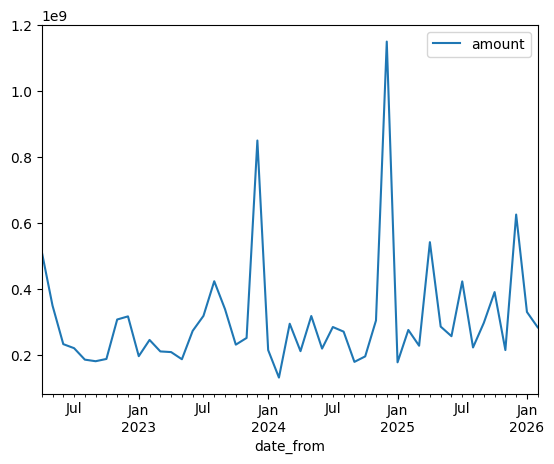

In [37]:
allowed = ['Monobank', 'Oschad', 'Privat', 'Pumb']

mono_df = savelife_df[savelife_df["source"].isin(allowed)]
mono_df = mono_df[["date_from", "amount"]]
mono_df["date_from"] = pd.to_datetime(mono_df["date_from"])
mono_df.set_index("date_from", inplace=True)
mono_df = mono_df.resample("M").sum()
mono_df.plot()

In [38]:
# H0 - ряд нестаціонарний
# p-value < 0.05 - відхиляємо H0

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [39]:
adf_test(mono_df.to_numpy())

Results of Dickey-Fuller Test:
Test Statistic                -7.280990e+00
p-value                        1.500613e-10
#Lags Used                     0.000000e+00
Number of Observations Used    4.600000e+01
Critical Value (1%)           -3.581258e+00
Critical Value (5%)           -2.926785e+00
Critical Value (10%)          -2.601541e+00
dtype: float64


In [ ]:
# p-value <<< 0.05 - ряж стаціонарний

In [40]:
# H0 - ряд стаціонарний
# p-value < 0.05 - відхиляємо H0

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [41]:
kpss_test(mono_df.to_numpy())

Results of KPSS Test:
Test Statistic           0.263497
p-value                  0.100000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_10184\4138616208.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


In [17]:
# p-value > 0.05 - ряж стаціонарний

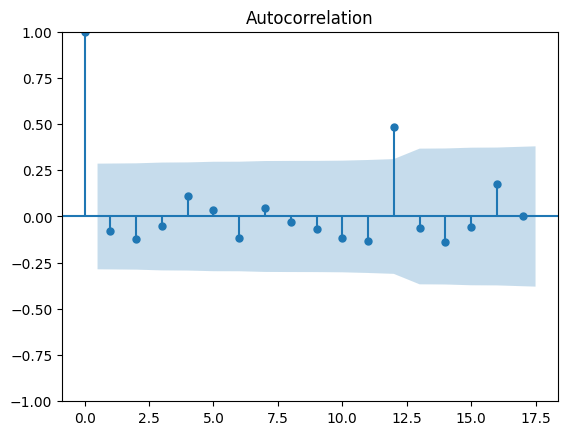

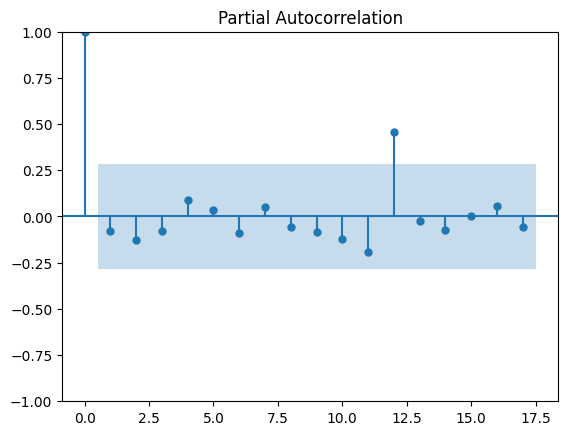

In [42]:
# ACF
plot_acf(mono_df)
plt.show()

# PACF
plot_pacf(mono_df)
plt.show()

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    mono_df,
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

result = model.fit()

print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             amount   No. Observations:                   47
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -959.928
Date:                            Sat, 14 Mar 2026   AIC                           1929.856
Time:                                    11:20:20   BIC                           1939.107
Sample:                                04-30-2022   HQIC                          1933.337
                                     - 02-28-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9984      0.023     44.223      0.000       0.954       1.043
ma.L1         -0.9499      0.342   

C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [ ]:
# Ljung–Box test
# H₀: The residuals are independently distributed and exhibit no autocorrelation up to the tested lag. p = 0.73 >> 0.05

# Jarque–Bera test
# H₀: The residuals are normally distributed. p = 0.00 << 0.05 -  відхиляємо

<Axes: xlabel='date_from'>

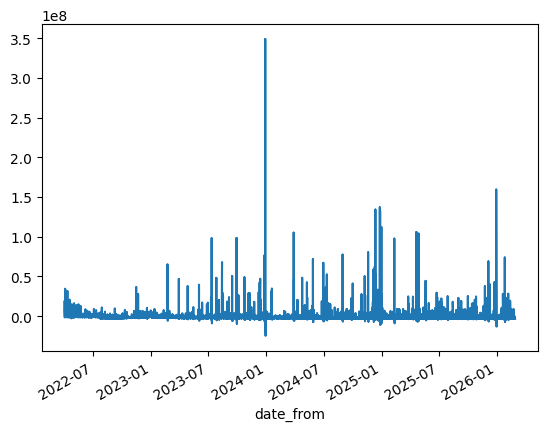

In [46]:
r.resid.plot()